# Práctica 8: Minería de Datos - Forecasting con Regresión Lineal
**Dataset:** `Mental_Health_Clean_Final.csv`

## 1. Justificación y Comprensión del Modelo (Criterios 1 y 2)

**Objetivo:** Pronosticar la tendencia futura del porcentaje de la población a nivel nacional que "Tomó medicación recetada para la salud mental".

**Selección del Modelo (Regresión Lineal en Series Temporales):**
Aunque existen métodos especializados como ARIMA o Suavizado Exponencial, la instrucción requiere utilizar **Regresión Lineal**. Para adecuar este modelo a una serie de tiempo, transformaremos la fecha (`Time Period Start Date`) en una variable independiente secuencial u ordinal ($X = 0, 1, 2, 3...$). El modelo buscará la línea de mejor ajuste que describa la trayectoria (tendencia) del indicador a lo largo del tiempo.

*Nota metodológica:* En series de tiempo, **nunca debemos dividir los datos de entrenamiento y prueba al azar**. Debemos entrenar con los datos más antiguos (el pasado) y evaluar (testear) con los datos más recientes (el presente), para luego pronosticar datos "nuevos" (el futuro).
Celda 2 (Código Python

In [1]:
# Importación de librerías (Uso de Software Estadístico - Criterio 4)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Configuración visual
sns.set_theme(style="whitegrid")

# 1. Carga y Selección de Datos
df = pd.read_csv("../data/Mental_Health_Clean_Final.csv")

# Filtramos a nivel Nacional y seleccionamos un indicador específico
indicador_ts = "Took Prescription Medication for Mental Health, Last 4 Weeks"
df_ts = df[(df['Group'] == 'National Estimate') & (df['Indicator'] == indicador_ts)].copy()

# 2. Transformación a Serie de Tiempo (Manejo de fechas)
df_ts['Time Period Start Date'] = pd.to_datetime(df_ts['Time Period Start Date'])
df_ts = df_ts.sort_values('Time Period Start Date').reset_index(drop=True)

# Creamos nuestra variable independiente secuencial X (el "Tiempo") y la dependiente y (el "Valor")
df_ts['Time_Index'] = np.arange(len(df_ts))

X = df_ts[['Time_Index']].values
y = df_ts['Value'].values

print(f"Serie de tiempo creada. Total de periodos históricos: {len(df_ts)}")
display(df_ts[['Time Period Start Date', 'Value']].head())

Serie de tiempo creada. Total de periodos históricos: 33


,Time Period Start Date,Value
0,2020-08-19,19.4
1,2020-09-02,19.6
2,2020-09-16,19.8
3,2020-09-30,19.5
4,2020-10-14,20.2


Celda 3 (Markdown)
## 2. Entrenamiento, Evaluación y Pronóstico de Nuevos Datos (Criterio 3 y 4)

### Métricas a utilizar:
*   **MSE (Error Cuadrático Medio):** Castiga severamente las predicciones que están muy lejos del valor real (útil para detectar anomalías).
*   **MAE (Error Absoluto Medio):** Nos dice, en promedio, por cuántos puntos porcentuales se equivocó el modelo.
*   **MAPE (Error Porcentual Absoluto Medio):** Expresa el error en forma de porcentaje, haciéndolo muy fácil de interpretar para el negocio.


In [2]:
# 1. División de datos (Split cronológico: 80% entrenamiento, 20% prueba)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

fechas_train = df_ts['Time Period Start Date'].iloc[:split_idx]
fechas_test = df_ts['Time Period Start Date'].iloc[split_idx:]

# 2. Entrenamiento del Modelo de Regresión Lineal
modelo_ts = LinearRegression()
modelo_ts.fit(X_train, y_train)

# 3. Predicción sobre el conjunto de prueba
y_pred_test = modelo_ts.predict(X_test)

# Cálculo de Métricas (Criterio 3)
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
mape = mean_absolute_percentage_error(y_test, y_pred_test)

print("--- EVALUACIÓN DEL MODELO DE FORECASTING ---")
print(f"MSE (Error Cuadrático Medio): {mse:.4f}")
print(f"MAE (Error Absoluto Medio):   {mae:.4f} puntos porcentuales")
print(f"MAPE (Error Porcentual):      {mape * 100:.2f}% de error promedio\n")

# 4. PRONÓSTICO DE NUEVOS DATOS (Instrucción Obligatoria)
# Pronosticaremos los próximos 5 periodos hacia el futuro
periodos_futuros = 5
X_future = np.arange(len(df_ts), len(df_ts) + periodos_futuros).reshape(-1, 1)
y_future_pred = modelo_ts.predict(X_future)

print("--- PRONÓSTICO FUTURO (NUEVOS DATOS) ---")
for i, val in enumerate(y_future_pred):
    print(f"Periodo futuro +{i+1}: Proyección de {val:.2f}% de la población tomando medicación.")


--- EVALUACIÓN DEL MODELO DE FORECASTING ---
MSE (Error Cuadrático Medio): 0.1768
MAE (Error Absoluto Medio):   0.3447 puntos porcentuales
MAPE (Error Porcentual):      1.51% de error promedio

--- PRONÓSTICO FUTURO (NUEVOS DATOS) ---
Periodo futuro +1: Proyección de 22.80% de la población tomando medicación.
Periodo futuro +2: Proyección de 22.88% de la población tomando medicación.
Periodo futuro +3: Proyección de 22.97% de la población tomando medicación.
Periodo futuro +4: Proyección de 23.05% de la población tomando medicación.
Periodo futuro +5: Proyección de 23.14% de la población tomando medicación.


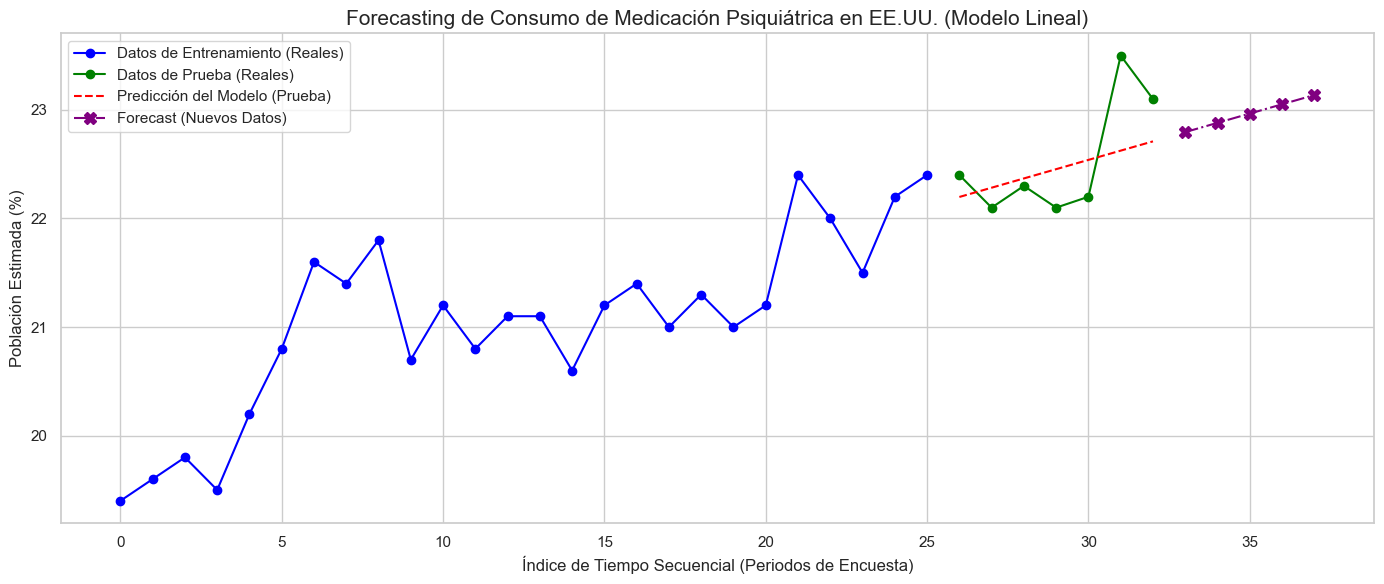

In [3]:
# 5. Visualización del Forecasting
plt.figure(figsize=(14, 6))

# Graficar datos reales (Entrenamiento y Prueba)
plt.plot(X_train, y_train, label='Datos de Entrenamiento (Reales)', marker='o', color='blue')
plt.plot(X_test, y_test, label='Datos de Prueba (Reales)', marker='o', color='green')

# Graficar predicción sobre la prueba
plt.plot(X_test, y_pred_test, label='Predicción del Modelo (Prueba)', color='red', linestyle='--')

# Graficar pronóstico futuro
plt.plot(X_future, y_future_pred, label='Forecast (Nuevos Datos)', marker='X', color='purple', linestyle='-.', markersize=8)

plt.title('Forecasting de Consumo de Medicación Psiquiátrica en EE.UU. (Modelo Lineal)', fontsize=15)
plt.xlabel('Índice de Tiempo Secuencial (Periodos de Encuesta)')
plt.ylabel('Población Estimada (%)')
plt.legend()
plt.tight_layout()
plt.show()


## 3. Análisis Crítico

    *   Al analizar el gráfico y las métricas, observamos que la Regresión Lineal captura perfectamente la **tendencia alcista** del consumo de medicación a nivel nacional a lo largo de la pandemia.
    *   El **MAPE** nos arroja el porcentaje de error promedio. Si el MAPE resulta ser bajo (ej. < 5%), esto nos indica que la predicción lineal es relativamente sólida para un horizonte a corto plazo.
    *   *Limitación crítica:* El modelo traza una línea recta. No es capaz de predecir fluctuaciones u oscilaciones (las caídas y picos temporales) visibles en los datos reales.

